# Notebook 6: Basic Data Analysis and Machine Learning

## Overview

This notebook demonstrates **exploratory data analysis (EDA) and machine learning classification** on preprocessed FTIR spectral data. You'll visualize spectral patterns, perform statistical analysis, apply dimensionality reduction, and build classification models.

### What You'll Learn

1. How to load and filter preprocessed FTIR data
2. How to visualize spectral patterns and variability
3. How to perform statistical analysis (ANOVA, correlation)
4. How to apply dimensionality reduction (PCA, t-SNE, UMAP, PLS-DA, OPLS-DA)
5. How to perform clustering analysis (K-means, hierarchical)
6. How to train and evaluate machine learning classification models
7. How to interpret model predictions with SHAP

### Prerequisites

You should have already:
- ✓ Completed Notebooks 1-5 OR have preprocessed FTIR data ready
- ✓ Data in CSV format with a label column (polymer type)
- ✓ Preprocessed data (denoised, baseline corrected, normalized)

### Analysis Workflow

This notebook follows a systematic analysis workflow:

1. **Data Loading & Filtering**: Load preprocessed data and select samples
2. **Exploratory Visualization**: Visualize spectral patterns and variability
3. **Statistical Analysis**: Identify significant wavenumbers (ANOVA, correlation)
4. **Dimensionality Reduction**: Reduce high-dimensional data for visualization
5. **Clustering Analysis**: Discover natural groupings in the data
6. **Machine Learning**: Build and evaluate classification models
7. **Model Interpretation**: Understand what drives predictions (SHAP)

### Available Analysis Methods

The `FTIRdataanalysis` class provides:

**Visualization:**
- Mean spectra by polymer type
- Overlay plots for comparison
- Coefficient of variation (CV) plots
- Correlation heatmaps

**Statistical Analysis:**
- ANOVA (identify discriminative wavenumbers)
- Correlation analysis

**Dimensionality Reduction:**
- PCA (Principal Component Analysis)
- t-SNE (t-Distributed Stochastic Neighbor Embedding)
- UMAP (Uniform Manifold Approximation and Projection)
- PLS-DA (Partial Least Squares Discriminant Analysis)
- OPLS-DA (Orthogonal PLS-DA)

**Clustering:**
- K-means clustering
- Hierarchical clustering

**Machine Learning:**
- 35+ pre-configured classification models
- Automated model comparison
- Hyperparameter tuning
- SHAP explainability analysis

### Expected Output

By the end of this notebook, you'll have:
- Visual understanding of spectral patterns
- Statistical insights into discriminative features
- Low-dimensional representations for visualization
- Trained classification models with performance metrics
- Interpretation of model predictions

---

## Step 1: Load Preprocessed Data

First, we'll load the preprocessed FTIR data created in previous notebooks.

In [1]:
# Import required modules
import polars as pl
import pandas as pd
from xpectrass import FTIRdataanalysis

print("="*80)
print("LOADING PREPROCESSED DATA")
print("="*80)

LOADING PREPROCESSED DATA


In [2]:
# Load the preprocessed data from Notebook 5
# Using 1st derivative data for enhanced spectral resolution
df = pd.read_csv('processed_data/combined_norm_data_excluded.csv.xz', compression='xz')

print(f"\nLoaded data shape: {df.shape}")
print(f"\nAvailable studies:")
print(df['study'].unique())
print("\nFirst few rows:")
print(df.head())


Loaded data shape: (12189, 1216)

Available studies:
['jung_2018' 'kedzierski_2019' 'kedzierski_2019_u' 'frond_2021'
 'villegas_camacho_2024_c4' 'villegas_camacho_2024_c8']

First few rows:
       study       sample_id  type environmental resolution  3100.0000  \
0  jung_2018   LL477006_1.16  HDPE             Y          H  -0.190274   
1  jung_2018   LL477006_5.15  HDPE             Y          H  -0.188868   
2  jung_2018   LL477006_6.01  HDPE             Y          H  -0.190780   
3  jung_2018   LL477006_7.01  HDPE             Y          H  -0.195473   
4  jung_2018  LL477006_14.01  HDPE             Y          H  -0.195159   

   3098.0000  3096.0000  3094.0000  3092.0000  ...  698.0000  696.0000  \
0  -0.190637  -0.191002  -0.190637  -0.190548  ... -0.116805 -0.153289   
1  -0.189536  -0.189981  -0.188998  -0.188998  ... -0.112286 -0.149625   
2  -0.190946  -0.191152  -0.190780  -0.190756  ... -0.130680 -0.179411   
3  -0.195592  -0.195782  -0.195592  -0.195572  ... -0.081309 -0.1232

In [3]:
print("\n" + "="*80)
print("FILTERING DATA")
print("="*80)

# Remove unknown samples dataset (focusing on labeled polymers)
df1 = df[df['study'] != 'kedzierski_2019_u']
# For this example, exclude one study to create a balanced dataset
df_sel = df1[df1['study'] != 'villegas_camacho_2024_c4']

print(f"\nAfter removing unknown samples: {df_sel.shape}")
print(f"\nUnique polymer types:")
print(df_sel['type'].unique())
print(f"\nSample distribution by polymer type:")
print(df_sel['type'].value_counts())


FILTERING DATA

After removing unknown samples: (5131, 1216)

Unique polymer types:
['HDPE' 'LDPE' 'Mixture' 'PA' 'PET' 'PP' 'PS' 'PVC' 'U1' 'AFL' 'CA' 'CE'
 'R' 'M1' 'M2' 'PEVA' 'PMMA' 'PE' 'PEF' 'PEL' 'PPL' 'PU' 'U2' 'ABS' 'AC'
 'CO' 'EAA' 'PC' 'PLA' 'SR']

Sample distribution by polymer type:
type
PP         1042
HDPE        936
PS          596
PET         548
LDPE        535
PVC         525
PE          295
PEF         148
R            64
CA           56
M1           54
PEVA         53
PPL          48
PA           40
Mixture      39
CE           28
PEL          25
PU           20
ABS          15
CO           14
M2           10
PC            9
PLA           8
AC            6
PMMA          5
U2            5
U1            4
AFL           1
EAA           1
SR            1
Name: count, dtype: int64


---

## Step 2: Filter and Select Data

Now we'll filter the data to focus on specific studies and polymer types with sufficient samples for analysis.

In [4]:
print("\n" + "="*80)
print("SELECTING POLYMER TYPES WITH SUFFICIENT SAMPLES")
print("="*80)

# Select the 8 most common polymer types (sufficient samples for ML)
selected_types = ['PP', 'HDPE', 'PS', 'PET', 'LDPE', 'PVC', 'PE', 'PEF']
df_norm = df_sel[df_sel['type'].isin(selected_types)]

print(f"\nSelected polymer types: {selected_types}")
print(f"Selected data shape: {df_sel.shape}")

print(f"\nFinal dataset shape: {df_norm.shape}")
print(f"Final sample distribution:")
print(df_norm['type'].value_counts())
print("="*80)

# Per-class per-dataset (study) counts
print('\nSamples per polymer type x study (dataset):')
ct = pd.crosstab(df_norm['type'], df_norm['study'], margins=True, margins_name='TOTAL')
print(ct.T)


SELECTING POLYMER TYPES WITH SUFFICIENT SAMPLES

Selected polymer types: ['PP', 'HDPE', 'PS', 'PET', 'LDPE', 'PVC', 'PE', 'PEF']
Selected data shape: (5131, 1216)

Final dataset shape: (4625, 1216)
Final sample distribution:
type
PP      1042
HDPE     936
PS       596
PET      548
LDPE     535
PVC      525
PE       295
PEF      148
Name: count, dtype: int64

Samples per polymer type x study (dataset):
type                      HDPE  LDPE   PE  PEF  PET    PP   PS  PVC  TOTAL
study                                                                     
frond_2021                   0     0   67    0   47    85   26   23    248
jung_2018                  436    35    0    0    1   262    7    1    742
kedzierski_2019              0     0  228  148    0   195   63    1    635
villegas_camacho_2024_c8   500   500    0    0  500   500  500  500   3000
TOTAL                      936   535  295  148  548  1042  596  525   4625


## 2a. Drop exact-duplicate spectra

After filtering, the dataset still contains rows whose **spectral values are bit-for-bit identical** even though they have **different `sample_id`s** (and the same `study` / `type`).

For example, in `villegas_camacho_2024_c8`:

| sample_id | type | spectral vector |
|-----------|------|------------------|
| `HDPE363` | HDPE | `[0.0175, 0.0175, 0.0134, …]` |
| `HDPE38`  | HDPE | `[0.0175, 0.0175, 0.0134, …]` ← identical |
| `PET142`  | PET  | `[…]` |
| `PET152`  | PET  | `[…]` ← identical |
| `PET221`  | PET  | `[…]` ← identical (3-way) |

There are **606 such duplicate groups** (one of them a triplet) — about 13% of the filtered data. They were almost certainly introduced by an earlier preprocessing step (e.g. interpolation, region-selection, or normalization producing the same output from genuinely different raw spectra), not by the FTIR instrument.

**Why it matters for ML.** If we leave them in and use a random train/test split, one copy of each duplicate is overwhelmingly likely to land in train and another copy in test. The model then "predicts" the test copies by literally memorizing the train copies, inflating accuracy without any real generalization.

**Fix.** Drop rows whose spectral content already exists earlier in the dataset (`keep='first'`). We rely on `pandas.duplicated`, which treats `NaN == NaN` so it correctly catches the villegas rows that share a single common NaN position.

In [5]:
def _is_wn(c):
    try:
        float(c); return True
    except Exception:
        return False

spectral_cols = [c for c in df_norm.columns if _is_wn(c)]
before = len(df_norm)
dup_mask = df_norm.duplicated(subset=spectral_cols, keep='first')
print(f'Duplicates dropped: {dup_mask.sum()}  ({before} -> {before - dup_mask.sum()})')
print('Duplicate breakdown:')
print(df_norm.loc[dup_mask, ["study", "type"]].value_counts())
df_norm = df_norm[~dup_mask].reset_index(drop=True)

# Per-class per-dataset (study) counts
print('\nSamples per polymer type x study (dataset):')
ct = pd.crosstab(df_norm['type'], df_norm['study'], margins=True, margins_name='TOTAL')
print(ct.T)
print('Shape:', df_norm.shape)

Duplicates dropped: 607  (4625 -> 4018)
Duplicate breakdown:
study                     type
villegas_camacho_2024_c8  LDPE    201
                          PS      201
                          PVC     200
                          PET       3
                          HDPE      2
Name: count, dtype: int64

Samples per polymer type x study (dataset):
type                      HDPE  LDPE   PE  PEF  PET    PP   PS  PVC  TOTAL
study                                                                     
frond_2021                   0     0   67    0   47    85   26   23    248
jung_2018                  436    35    0    0    1   262    7    1    742
kedzierski_2019              0     0  228  148    0   195   63    1    635
villegas_camacho_2024_c8   498   299    0    0  497   500  299  300   2393
TOTAL                      934   334  295  148  545  1042  395  325   4018
Shape: (4018, 1216)


---

## Step 3: Initialize FTIRdataanalysis

In [6]:
print("\n" + "="*80)
print("INITIALIZING FTIRdataanalysis")
print("="*80)

# Initialize the analysis class
# This class handles all visualization, statistical analysis, and machine learning
fda = FTIRdataanalysis(
    df=df_norm,
    dataset_name='Combined dataset',
    label_column="type",
    exclude_columns=['study', 'sample_id', 'environmental', 'resolution'],  # Exclude metadata
    random_state=42,  # For reproducibility
    n_jobs=-1,  # Use all CPU cores for parallel processing
)

print(f"\n✓ FTIRdataanalysis initialized successfully")
print(f"  Dataset: Combined dataset")
print(f"  Samples: {len(df_norm)}")
print(f"  Features: {df_norm.shape[1] - len(['type', 'study', 'sample_id', 'environmental', 'resolution'])}")
print(f"  Polymer types: {df_norm['type'].nunique()}")
print("="*80)


INITIALIZING FTIRdataanalysis

✓ FTIRdataanalysis initialized successfully
  Dataset: Combined dataset
  Samples: 4018
  Features: 1211
  Polymer types: 8


---

## Step 4: Exploratory Data Visualization

### 4.1 Mean Spectra by Polymer Type

Visualize the mean (average) spectrum for each polymer type. This shows the characteristic spectral signatures that distinguish different polymers.

Auto-detected: Absorbance
Plot saved to: mean_spectra/mean_spectra_by_class_Combined dataset.pdf


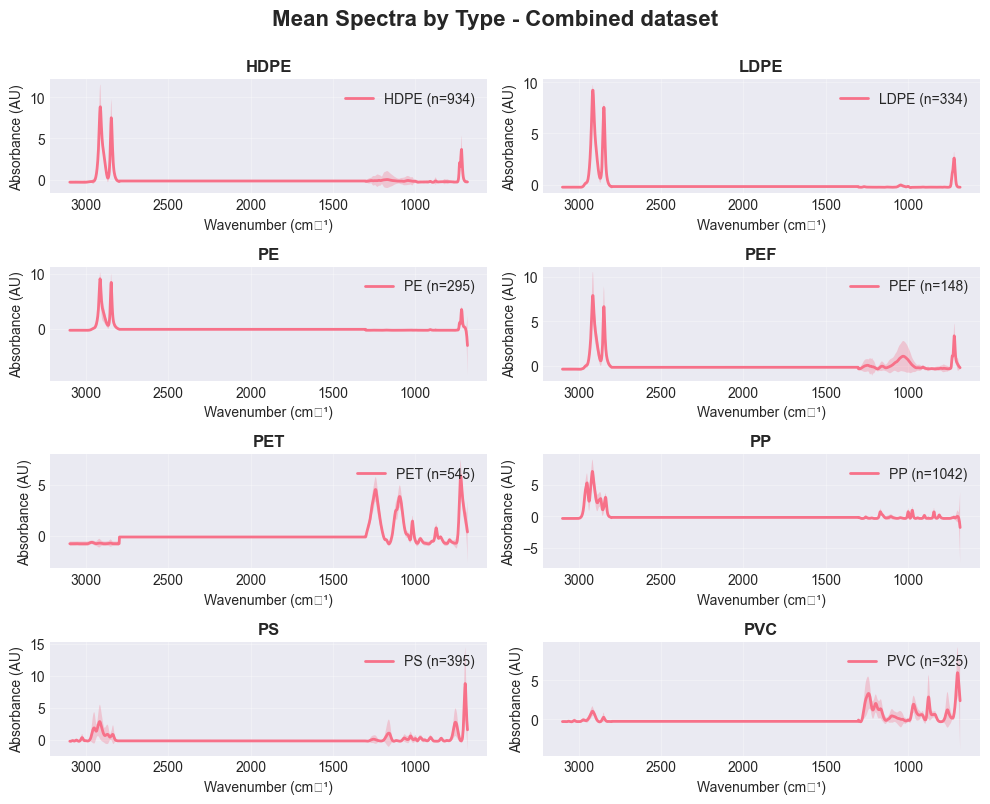

In [7]:
# Plot mean spectra for each polymer type in separate subplots
# This shows the characteristic spectral pattern for each polymer
fda.plot_mean_spectra(
    title="Mean Spectra by Type",
    figsize=(10, 8),
    save_plot=True,
    save_path='mean_spectra',
)

### 4.2 Overlay Mean Spectra

Plot all mean spectra overlaid on the same axes for direct comparison. This helps identify spectral regions where polymers differ most.

In [ ]:
# Overlay all mean spectra on one plot for direct comparison
# Look for regions where spectra differ most - these are discriminative features
fda.plot_overlay_spectra(
    title="Mean Spectra overlay",
    figsize=(16, 4),
    save_plot=True,
    save_path="mean_spectra",
)

### 4.3 Coefficient of Variation (CV) Plot

The CV plot shows spectral variability within each polymer type. High CV indicates regions with high within-group variability, which may be due to sample heterogeneity or measurement noise.

In [ ]:
# Plot coefficient of variation (CV) to assess spectral variability
# Low CV = consistent spectra within polymer type
# High CV = high variability (may indicate sample heterogeneity)
fda.plot_cv(
    title="Spectral Variability by Type",
    figsize=(16, 4),
    save_plot=True,
    save_path="mean_spectra",
)

### 4.4 Correlation Heatmap

Shows mean spectra for all polymer types as a heatmap. Brighter regions indicate higher absorbance, darker regions indicate lower absorbance.

In [ ]:
# Heatmap showing mean spectra for all polymer types
# Columns = wavenumbers, Rows = polymer types
# Color intensity = absorbance value
fda.plot_heatmap(
    figsize=(5, 4),
    save_plot=True,
    save_path="mean_spectra",
)

---

## Step 5: Statistical Analysis

### 5.1 ANOVA Analysis

Analysis of Variance (ANOVA) identifies wavenumbers where polymer types differ significantly. High F-values indicate discriminative features.

In [ ]:
# Perform ANOVA to identify discriminative wavenumbers
# High F-values = large between-group variance relative to within-group variance
# These wavenumbers are most useful for classification
fda.perform_anova(
    figsize=(16, 8),
    save_plot=True,
    save_path="mean_spectra",
)

### 5.2 Correlation Analysis

Examines correlations between wavenumbers. Highly correlated features provide redundant information.

In [ ]:
# Correlation analysis between wavenumbers
# Dark red/blue = highly correlated features (redundant information)
# White = uncorrelated features (independent information)
fda.plot_correlation(
    figsize=(16, 12),
    save_plot=True,
    save_path="mean_spectra",
)

---

## Step 6*: remove zero interpolated part and reinitialize FTIRdataanalysis

Now we'll filter the data to focus on specific studies and polymer types with sufficient samples for analysis.

In [8]:
# Remove wavenumber columns in the 1300-2800 cm⁻¹ range (zero-interpolated region)
# Keep only wavenumbers < 1300 and > 2800
spectral_cols = [c for c in df_norm.columns if c.replace('.', '', 1).isdigit()]
non_spectral_cols = [c for c in df_norm.columns if c not in spectral_cols]
filtered_spectral_cols = [c for c in spectral_cols if float(c) < 1300 or float(c) > 2800]
df_norm = df_norm[non_spectral_cols + filtered_spectral_cols]

print(f"\nAfter removing 1300-2800 cm⁻¹ region:")
print(f"  Removed {len(spectral_cols) - len(filtered_spectral_cols)} wavenumber columns")
print(f"  Remaining spectral columns: {len(filtered_spectral_cols)}")

print(f"\nFinal dataset shape: {df_norm.shape}")
print(f"Final sample distribution:")
print(df_norm['type'].value_counts())
print("="*80)

print("\n" + "="*80)
print("INITIALIZING FTIRdataanalysis")
print("="*80)

# Initialize the analysis class
# This class handles all visualization, statistical analysis, and machine learning
fda = FTIRdataanalysis(
    df=df_norm,
    dataset_name='Combined dataset',
    label_column="type",
    exclude_columns=['study', 'sample_id', 'environmental', 'resolution'],  # Exclude metadata
    random_state=42,  # For reproducibility
    n_jobs=-1,  # Use all CPU cores for parallel processing
)

print(f"\n✓ FTIRdataanalysis initialized successfully")
print(f"  Dataset: Combined dataset")
print(f"  Samples: {len(df_norm)}")
print(f"  Features: {df_norm.shape[1] - len(['type', 'study', 'sample_id', 'environmental', 'resolution'])}")
print(f"  Polymer types: {df_norm['type'].nunique()}")
print("="*80)


After removing 1300-2800 cm⁻¹ region:
  Removed 751 wavenumber columns
  Remaining spectral columns: 460

Final dataset shape: (4018, 465)
Final sample distribution:
type
PP      1042
HDPE     934
PET      545
PS       395
LDPE     334
PVC      325
PE       295
PEF      148
Name: count, dtype: int64

INITIALIZING FTIRdataanalysis

✓ FTIRdataanalysis initialized successfully
  Dataset: Combined dataset
  Samples: 4018
  Features: 460
  Polymer types: 8


---

## Step 6: Dimensionality Reduction

High-dimensional spectral data (1000+ features) can be reduced to 2-3 dimensions for visualization while preserving important patterns.

### 6.1 Principal Component Analysis (PCA)

PCA finds linear combinations of features that explain maximum variance. PC1 and PC2 typically capture the most important spectral variations.

In [ ]:
# PCA: Linear dimensionality reduction
# standardize=True: Standardize features before PCA
# handle_missing="zero": Replace any NaN values with 0
# Look for:
#   - Clear separation between polymer types
#   - Explained variance in PC1 and PC2
#   - Outliers
fda.plot_pca(
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

### 6.2 t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE preserves local structure better than PCA, often revealing clusters not visible in PCA. Good for visualizing natural groupings.

In [ ]:
# t-SNE: Non-linear dimensionality reduction
# perplexity=50: Balance between local and global structure (5-50 typical)
# n_iter=1000: Number of optimization iterations
# pca_components=20: Pre-reduce to 20 dimensions with PCA (faster, often better)
# Look for:
#   - Tight clusters of same polymer type
#   - Separation between different types
#   - Mixed clusters may indicate similar polymers
fda.plot_tsne(
    perplexity=50,
    n_iter=1000,
    pca_components=30,
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

### 6.3 UMAP (Uniform Manifold Approximation and Projection)

UMAP is faster than t-SNE and often preserves both local and global structure better. Excellent for large datasets.

In [ ]:
# UMAP: Modern non-linear dimensionality reduction
# n_neighbors=100: Size of local neighborhood (2-200 typical)
# min_dist=0.5: Minimum distance between points in embedding (0.0-0.99)
# pca_components=20: Pre-reduce dimensionality
# Look for:
#   - Balance of local and global structure
#   - Clear polymer type clusters
#   - Overall topology of the data
fda.plot_umap(
    n_neighbors=30,
    min_dist=0.3,
    pca_components=30,
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

### 6.4 PLS-DA (Partial Least Squares Discriminant Analysis)

PLS-DA is a supervised method that finds components maximizing separation between classes. Better than PCA for classification.

In [ ]:
# PLS-DA: Supervised dimensionality reduction for classification
# n_components=20: Number of PLS components to extract
# This method uses class labels to find components that maximize separation
fda.plot_plsda(
    n_components=30,
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

### 6.5 OPLS-DA (Orthogonal PLS-DA)

OPLS-DA separates variation related to class separation from orthogonal variation (noise). Better interpretability than PLS-DA.

In [ ]:
# OPLS-DA: Orthogonal PLS-DA
# n_components=1: Predictive components
# n_orthogonal=2: Orthogonal (uncorrelated) components
# Separates class-related variation from unrelated variation
fda.plot_oplsda(
    n_components=1,
    n_orthogonal=2,
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

---

## Step 7: Clustering Analysis

Clustering discovers natural groupings in unlabeled data. Compare clustering results to true labels to assess data structure.

### 7.1 K-means Clustering

K-means partitions data into k clusters by minimizing within-cluster variance. Good for spherical, well-separated clusters.

In [ ]:
# K-means clustering
# n_clusters=8: Number of clusters (should match number of polymer types)
# pca_components=20: Reduce to 20 dimensions before clustering
# n_components_clustering=10: Use first 10 PCA components for clustering
# k_range=(2,11): Test elbow method for optimal k
# Look for:
#   - Agreement between clusters and true polymer types
#   - Elbow in within-cluster sum of squares plot
fda.plot_kmeans_clus(
    n_clusters=8,
    pca_components=30,
    n_components_clustering=50,
    k_range=(2, 11),
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

### 7.2 Hierarchical Clustering

Hierarchical clustering builds a tree of clusters (dendrogram). Useful for understanding hierarchical relationships between polymer types.

In [ ]:
# Hierarchical clustering
# n_clusters=8: Cut dendrogram to form 8 clusters
# pca_components=20: Pre-reduce dimensionality
# n_components_clustering=10: Use 10 PCA components for clustering
# n_samples_dendro=100: Plot dendrogram for 100 samples (faster)
# Look for:
#   - Dendrogram structure (which polymers cluster together)
#   - Height of merges (distance between clusters)
fda.plot_hierarchical_clus(
    n_clusters=8,
    pca_components=30,
    n_components_clustering=50,
    n_samples_dendro=100,
    standardize=True,
    handle_missing="zero",
    figsize=(8, 8),
    save_plot=True,
    save_path=None,
)

---

## Step 8: Machine Learning Classification

Now we'll train and evaluate machine learning models to classify polymer types based on FTIR spectra.

### 8.1 Prepare Data for Machine Learning

Split data into training and testing sets.

### 8.1a*. If imputation is required: spectral-aware impute and reinitialize

This step is **spectral-aware** in two ways:

**1. Counting** — instead of a single "total NaN" number, we report what matters for FTIR data quality:
- **Per-wavenumber NaN fraction** (which columns have NaN, the worst ones by cm⁻¹) — flags bad spectral channels.
- **Per-spectrum NaN count** (how many wavenumbers are missing in each spectrum) — flags bad scans.
- **Max contiguous NaN run per spectrum** (the longest *spectral gap* in a row) — a 1-sample gap is harmless, a 50-sample gap erases real features.

**2. Imputation** — FTIR absorbance is a smooth function of wavenumber, so adjacent wavenumbers are highly correlated. The right way to fill a missing value at cm⁻¹ = 1500 is to **interpolate from the values at cm⁻¹ = 1498 and 1502 within the same spectrum**, not from the average of cm⁻¹ = 1500 across other spectra. We therefore split the strategies into:
- **Spectral (row-wise along the wavenumber axis):** `'linear'` *(default, recommended)*, `'nearest'`, `'cubic'`, `'pchip'`, `'akima'`. These use only the same spectrum's neighbours and respect the physical ordering of wavenumbers.
- **Non-spectral (column statistics across spectra):** `'mean'`, `'median'`, `'iterative'`, `'zero'`. These ignore wavenumber ordering. Keep as a fallback (`'iterative'` can be useful when missingness patterns are structured); `'zero'` remains discouraged because 0 is a real FTIR value.

For most FTIR datasets the default `'linear'` is appropriate, fast, and well-conditioned.

In [9]:
# === Spectral-aware NaN-handling configuration ===
NAN_DROP_THRESHOLD = 0.8          # drop a wavenumber column if its NaN fraction is > this
IMPUTATION_STRATEGY = 'akima'    # spectral (row-wise, recommended): 'linear' | 'nearest' | 'cubic' | 'pchip' | 'akima'
                                  # non-spectral (column stats):     'mean' | 'median' | 'iterative' | 'zero'
# ==================================================

import numpy as np
import pandas as pd

SPECTRAL_METHODS = {'linear', 'nearest', 'cubic', 'pchip', 'akima', 'quadratic'}

# Sort spectral columns by wavenumber so row-wise interpolation uses physically adjacent points
spec_cols_pre = sorted([c for c in df_norm.columns if _is_wn(c)], key=lambda c: float(c))
non_spec_cols = [c for c in df_norm.columns if c not in spec_cols_pre]
wn = np.array([float(c) for c in spec_cols_pre])

X_pre = df_norm[spec_cols_pre]
nan_mat = X_pre.isna().values

# ----------- Spectral-aware NaN counting -----------
per_col = nan_mat.mean(axis=0)            # per-wavenumber NaN fraction
per_row = nan_mat.sum(axis=1)             # per-spectrum NaN count

print(f'Spectra:                 {len(X_pre)}')
print(f'Spectral columns:        {len(spec_cols_pre)}  (range {wn.min():.0f}–{wn.max():.0f} cm⁻¹)')
print(f'Total NaN cells:         {int(nan_mat.sum())} / {nan_mat.size}  ({nan_mat.mean():.2%})')

print('\nPer-wavenumber NaN profile:')
print(f'  All-NaN columns:                 {int((per_col == 1.0).sum())}')
print(f'  > {NAN_DROP_THRESHOLD:.0%} NaN columns:              {int((per_col > NAN_DROP_THRESHOLD).sum())}')
print(f'  Any-NaN columns:                 {int((per_col > 0).sum())}')
if (per_col > 0).any():
    worst_idx = np.argsort(-per_col)[:5]
    worst = [(float(spec_cols_pre[i]), float(per_col[i])) for i in worst_idx if per_col[i] > 0]
    print(f'  Worst columns [cm⁻¹, NaN frac]:  {worst}')

print('\nPer-spectrum NaN profile:')
print(f'  Spectra with any NaN:            {int((per_row > 0).sum())}  ({(per_row > 0).mean():.2%})')
print(f'  Mean / median / max NaN/row:     {per_row.mean():.2f} / {np.median(per_row):.0f} / {per_row.max()}')

if nan_mat.any():
    # Longest contiguous NaN run per row (the "spectral gap")
    def _max_run(row):
        longest = run = 0
        for v in row:
            run = run + 1 if v else 0
            if run > longest:
                longest = run
        return longest
    gaps = np.array([_max_run(r) for r in nan_mat])
    print(f'  Max contiguous NaN run/row:      mean={gaps.mean():.2f}  max={int(gaps.max())}  '
          f'rows with gap>=5: {int((gaps >= 5).sum())}  >=20: {int((gaps >= 20).sum())}')

# ----------- Drop wavenumber columns above NaN threshold -----------
keep_mask = per_col <= NAN_DROP_THRESHOLD
keep_cols = [c for c, k in zip(spec_cols_pre, keep_mask) if k]
dropped_cols = [c for c, k in zip(spec_cols_pre, keep_mask) if not k]
print(f'\nDropping {len(dropped_cols)} columns above {NAN_DROP_THRESHOLD:.0%} NaN; keeping {len(keep_cols)}')
if dropped_cols:
    print(f'  Dropped wavenumbers (cm⁻¹): {[float(c) for c in dropped_cols[:10]]}{" ..." if len(dropped_cols) > 10 else ""}')

# ----------- Imputation -----------
X_keep = df_norm[keep_cols].astype(float).values
wn_keep = np.array([float(c) for c in keep_cols])

if IMPUTATION_STRATEGY in SPECTRAL_METHODS:
    # Row-wise interpolation along the wavenumber axis.
    # Each NaN is filled by interpolating between its neighbouring wavenumbers
    # *within the same spectrum*, NOT from other spectra. This respects the fact
    # that FTIR absorbance is a smooth function of cm⁻¹.
    df_for_interp = pd.DataFrame(X_keep, columns=wn_keep)
    interp = df_for_interp.interpolate(
        method=IMPUTATION_STRATEGY,
        axis=1,
        limit_direction='both',  # fill leading/trailing NaN by edge extrapolation
    )
    X_imp = interp.values
    # Safety net: any remaining NaN (e.g. all-NaN row) falls back to column mean
    if np.isnan(X_imp).any():
        col_means = np.nanmean(X_imp, axis=0)
        bad = np.where(np.isnan(X_imp))
        X_imp[bad] = np.take(col_means, bad[1])
        print(f"  Note: {len(bad[0])} cells in all-NaN rows fell back to column mean.")
elif IMPUTATION_STRATEGY == 'iterative':
    from sklearn.experimental import enable_iterative_imputer  # noqa: F401
    from sklearn.impute import IterativeImputer
    X_imp = IterativeImputer(random_state=42, max_iter=10).fit_transform(X_keep)
elif IMPUTATION_STRATEGY in ('mean', 'median'):
    from sklearn.impute import SimpleImputer
    X_imp = SimpleImputer(strategy=IMPUTATION_STRATEGY).fit_transform(X_keep)
elif IMPUTATION_STRATEGY == 'zero':
    print('  WARNING: zero-imputation can introduce artificial patterns in FTIR (0 = real "no absorbance")')
    X_imp = np.nan_to_num(X_keep, nan=0.0)
else:
    raise ValueError(f'Unknown IMPUTATION_STRATEGY: {IMPUTATION_STRATEGY!r}')

# ----------- Rebuild df_norm -----------
df_norm = pd.concat(
    [df_norm[non_spec_cols].reset_index(drop=True),
     pd.DataFrame(X_imp, columns=keep_cols)],
    axis=1,
)
remaining = int(df_norm[keep_cols].isna().sum().sum())
mode = 'spectral (row-wise)' if IMPUTATION_STRATEGY in SPECTRAL_METHODS else 'non-spectral (column stats)'
print(f"\nImputed with '{IMPUTATION_STRATEGY}' [{mode}]. Remaining NaN cells: {remaining}")
print(f'df_norm shape: {df_norm.shape}')

# ----------- Re-initialize FTIRdataanalysis -----------
fda = FTIRdataanalysis(
    df=df_norm,
    dataset_name='Combined dataset',
    label_column="type",
    exclude_columns=['study', 'sample_id', 'environmental', 'resolution'],
    random_state=42,
    n_jobs=-1,
)
print(f"\n✓ FTIRdataanalysis re-initialized: {len(df_norm)} samples, "
      f"{df_norm.shape[1] - len(['type','study','sample_id','environmental','resolution'])} features, "
      f"{df_norm['type'].nunique()} polymer types")
print('='*80)


Spectra:                 4018
Spectral columns:        460  (range 680–3100 cm⁻¹)
Total NaN cells:         3276 / 1848280  (0.18%)

Per-wavenumber NaN profile:
  All-NaN columns:                 0
  > 80% NaN columns:              1
  Any-NaN columns:                 1
  Worst columns [cm⁻¹, NaN frac]:  [(680.0, 0.8153310104529616)]

Per-spectrum NaN profile:
  Spectra with any NaN:            3276  (81.53%)
  Mean / median / max NaN/row:     0.82 / 1 / 1
  Max contiguous NaN run/row:      mean=0.82  max=1  rows with gap>=5: 0  >=20: 0

Dropping 1 columns above 80% NaN; keeping 459
  Dropped wavenumbers (cm⁻¹): [680.0]

Imputed with 'akima' [spectral (row-wise)]. Remaining NaN cells: 0
df_norm shape: (4018, 464)

✓ FTIRdataanalysis re-initialized: 4018 samples, 459 features, 8 polymer types


In [10]:
print("\n" + "="*80)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*80)

# Prepare data for ML: split into training and testing sets
# test_size=0.2: Use 20% of data for testing, 80% for training
# Stratified split ensures balanced representation of each polymer type
data_dict = fda.ml_prepare_data(
    test_size=0.2,
)

print(f"\n✓ Data prepared successfully")
print(f"  Training samples: {len(data_dict['X_train'])}")
print(f"  Testing samples: {len(data_dict['X_test'])}")
print("="*80)


PREPARING DATA FOR MACHINE LEARNING

✓ Data prepared successfully
  Training samples: 3214
  Testing samples: 804


### 8.2 Available Models

Xpectrass provides 40 pre-configured classification models across different algorithm families.

In [11]:
# View all available pre-configured models
# Includes: Linear models, tree-based, SVMs, neural networks, ensemble methods
print("\n" + "="*80)
print("AVAILABLE CLASSIFICATION MODELS")
print("="*80)
print(fda.available_models())
print("="*80)


AVAILABLE CLASSIFICATION MODELS
{'Logistic Regression': LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42), 'Ridge Classifier': RidgeClassifier(random_state=42), 'Logistic Regression (Ridge)': LogisticRegression(max_iter=1000, n_jobs=-1, penalty='l2', random_state=42,
                   solver='saga'), 'Logistic Regression (Lasso)': LogisticRegression(max_iter=1000, n_jobs=-1, penalty='l1', random_state=42,
                   solver='saga'), 'Logistic Regression (ElasticNet)': LogisticRegression(l1_ratio=0.5, max_iter=1000, n_jobs=-1, penalty='elasticnet',
                   random_state=42, solver='saga'), 'Linear Discriminant Analysis': LinearDiscriminantAnalysis(), 'Quadratic Discriminant Analysis': QuadraticDiscriminantAnalysis(), 'SGD Classifier': SGDClassifier(n_jobs=-1, random_state=42), 'SGD Classifier (Ridge)': SGDClassifier(n_jobs=-1, random_state=42), 'SGD Classifier (Lasso)': SGDClassifier(n_jobs=-1, penalty='l1', random_state=42), 'SGD Classifier (ElasticNet)':

### 8.3 Train and Evaluate a Single Model

Train a single model (XGBoost) and evaluate its performance.


TRAINING SINGLE MODEL: XGBoost (100)
Confusion matrix saved to: ML


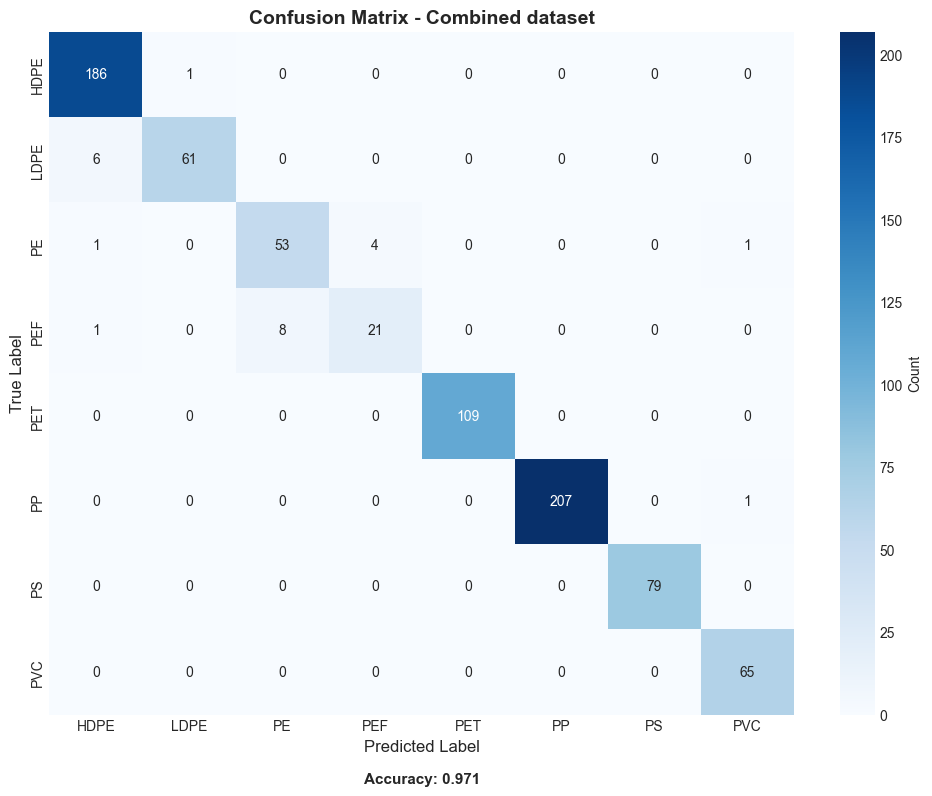

OVERALL METRICS:
--------------------------------------------------------------------------------
  Accuracy:              0.9714
  Precision (macro):     0.9527
  Precision (weighted):  0.9711
  Recall (macro):        0.9373
  Recall (weighted):     0.9714
  F1 (macro):            0.9439
  F1 (weighted):         0.9708
  MCC:                   0.9656
  Cohen's Kappa:         0.9655
  Jaccard (macro):       0.9031
  Jaccard (weighted):    0.9474
  ROC-AUC:               N/A (no probabilities)
Overall Results:
 {'accuracy': 0.9713930348258707, 'precision_macro': 0.9527044458859513, 'precision_weighted': 0.9710572278694386, 'recall_macro': 0.9373246950061516, 'recall_weighted': 0.9713930348258707, 'f1_macro': 0.9439403662660497, 'f1_weighted': 0.970754630002808, 'mcc': 0.9656052424730707, 'cohens_kappa': 0.9655065640493786, 'jaccard_macro': 0.9031172967177686, 'jaccard_weighted': 0.9474290136741161, 'roc_auc_ovr_macro': nan, 'roc_auc_ovr_weighted': nan}
Per Class Results:
   class  suppo

In [12]:
print("\n" + "="*80)
print("TRAINING SINGLE MODEL: XGBoost (100)")
print("="*80)

# Train and evaluate XGBoost model
# model_name: Use pre-configured model
# cv_folds=5: Use 5-fold cross-validation
# plot_confusion=True: Show confusion matrix
# print_test_result=True: Print detailed metrics
results = fda.run_a_model(
    model_name='XGBoost (100)',
    model=None,
    cv_folds=5,
    plot_confusion=True,
    save_plot_path='ML',
    print_test_result=True,
)

print("="*80)

### 8.4 Train and Compare All Models

Train all 35+ models and compare their performance. This identifies the best models for your data.

In [13]:
print("\n" + "="*80)
print("TRAINING AND COMPARING ALL MODELS")
print("="*80)
print("This will train 35+ models and may take several minutes...\n")

# Train all available models and compare performance
# plot_comparision=True: Show comparison plots
# accuracy_threshold=0.9: Only show models with >90% accuracy
# top_n_methods=20: Show top 20 models
results_all = fda.run_all_models(
    plot_comparison=True,
    accuracy_threshold=0.9,
    top_n_methods=20,
    save_plot_path='ML'
)

print("\n" + "="*80)
print("MODEL COMPARISON COMPLETE")
print("="*80)


TRAINING AND COMPARING ALL MODELS
This will train 35+ models and may take several minutes...


EVALUATING ALL MODELS - Combined dataset

[1/41] Evaluating Logistic Regression...
  ✓ Accuracy: 0.9764 | Train time: 0.09s
[2/41] Evaluating Ridge Classifier...
  ✓ Accuracy: 0.9353 | Train time: 0.01s
[3/41] Evaluating Logistic Regression (Ridge)...
  ✓ Accuracy: 0.9714 | Train time: 15.10s
[4/41] Evaluating Logistic Regression (Lasso)...
  ✓ Accuracy: 0.9664 | Train time: 27.23s
[5/41] Evaluating Logistic Regression (ElasticNet)...
  ✓ Accuracy: 0.9701 | Train time: 31.03s
[6/41] Evaluating Linear Discriminant Analysis...
  ✓ Accuracy: 0.9652 | Train time: 0.07s
[7/41] Evaluating Quadratic Discriminant Analysis...
  ERROR: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.
  ✗ Failed
[8/41] Evaluating SGD Classifier...
  ✓ Accuracy: 0.9590 | Train time: 0.09s
[9/41] Evaluating SGD Classifier (Ridge)...
  ✓ Accuracy: 0.9590 | Tr

### 8.5 Hyperparameter Tuning

Fine-tune the top model(s) by optimizing hyperparameters using grid search.

In [ ]:
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)
print("Tuning top model(s) using grid search with cross-validation...\n")

# Perform hyperparameter tuning on the top model
# number_of_models=1: Tune only the best model
# Uses grid search with cross-validation
tuning_results = fda.model_parameter_tuning(number_of_models=1)

print("\n" + "="*80)
print("HYPERPARAMETER TUNING COMPLETE")
print("="*80)

---

## Step 9: Model Interpretation with SHAP

SHAP (SHapley Additive exPlanations) explains model predictions by showing which features (wavenumbers) contribute most to each prediction.

### 9.1 Global SHAP Analysis

Shows overall feature importance across all predictions.

In [14]:
print("\n" + "="*80)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*80)

# Explain model predictions with SHAP
# model_name: Which model to explain
# max_display=20: Show top 20 most important features
# sample_size=100: Use 100 samples for SHAP (faster, representative)
# Generates:
#   - Summary plot (feature importance)
#   - Bar plot (mean absolute SHAP values)
#   - Beeswarm plot (feature effects)
shap_results = fda.explain_by_shap(
    model_name='XGBoost (100)',
    max_display=20,
    sample_size=100,
    test_size=0.2,
    cv_folds=5,
    save_plot_path='ML'
)

print("\n✓ SHAP analysis complete")
print("="*80)


SHAP EXPLAINABILITY ANALYSIS

SHAP FEATURE IMPORTANCE ANALYSIS

Data mode: Using SCALED data for SHAP computation, RAW data for visualization

Sampling 100 background samples from 3214 training samples...

Model: XGBClassifier
Using TreeExplainer (fast for tree-based models)...
Computing SHAP values for 804 test samples...


 96%|=================== | 6149/6432 [00:18<00:00]       

SHAP computation completed in 18.21s

Multiclass problem detected: 8 classes

Using 'grid' layout for 8 classes

Generating SHAP summary plots for each class...
   → Saved: ML/shap_summary_Combined dataset.pdf

Generating SHAP bar plots (mean absolute impact)...
   → Saved: ML/shap_bar_Combined dataset.pdf

Generating combined global feature importance plot...
   → Saved: ML/shap_global_Combined dataset.pdf

TOP 10 FEATURES PER CLASS (by mean absolute SHAP value)

HDPE:
----------------------------------------
   1.     2842.0  |  Impact: 0.6090
   2.     2844.0  |  Impact: 0.5287
   3.      896.0  |  Impact: 0.3202
   4.      836.0  |  Impact: 0.3054
   5.      704.0  |  Impact: 0.2770
   6.     2958.0  |  Impact: 0.2613
   7.      724.0  |  Impact: 0.1983
   8.     2924.0  |  Impact: 0.1590
   9.      702.0  |  Impact: 0.1366
  10.      736.0  |  Impact: 0.1265

LDPE:
----------------------------------------
   1.     2912.0  |  Impact: 0.5636
   2.     2854.0  |  Impact: 0.5327
   3

### 9.2 Local SHAP Analysis

Explains a single prediction by showing which features pushed the model toward or away from each class.


SHAP Decision Plot for Sample 0
True Label: HDPE


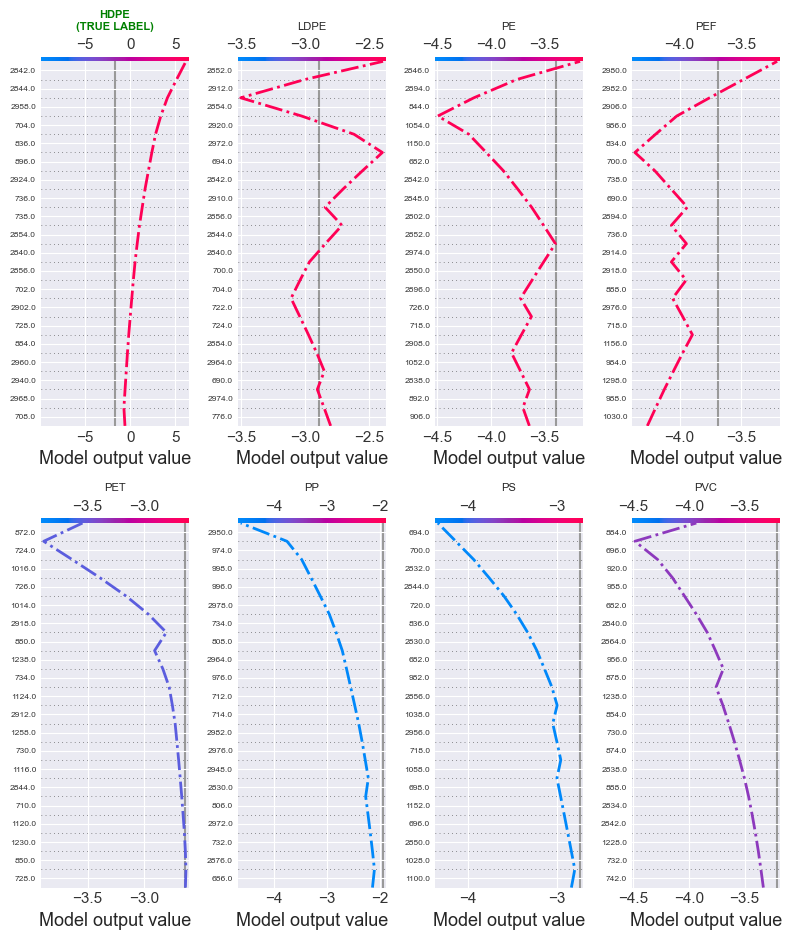

In [15]:
# Local SHAP plot for a single prediction
# sample_index=0: Explain prediction for first test sample
# Shows:
#   - Base value (average model output)
#   - How each feature pushes prediction toward final value
#   - Red = pushes prediction higher, Blue = pushes lower
fda.local_shap_plot(
    sample_index=0,
    figsize=(10, 8),
    save_plot_path=None
)

---

## Summary and Conclusions

### What We Accomplished

In this notebook, we performed a comprehensive analysis of FTIR spectral data:

1. ✓ **Data Loading & Filtering**: Loaded and filtered preprocessed data
2. ✓ **Exploratory Visualization**: Visualized spectral patterns and variability
3. ✓ **Statistical Analysis**: Identified discriminative wavenumbers (ANOVA, correlation)
4. ✓ **Dimensionality Reduction**: Reduced data to 2D for visualization (PCA, t-SNE, UMAP, PLS-DA, OPLS-DA)
5. ✓ **Clustering**: Discovered natural groupings (K-means, hierarchical)
6. ✓ **Machine Learning**: Trained and compared 35+ classification models
7. ✓ **Model Interpretation**: Explained predictions with SHAP

### Key Insights

From the analysis, you should now understand:

- **Spectral Signatures**: Each polymer type has characteristic FTIR peaks
- **Discriminative Features**: Which wavenumbers are most useful for classification (ANOVA, SHAP)
- **Data Structure**: How polymer types cluster in reduced dimensions
- **Model Performance**: Which models work best for your data
- **Feature Importance**: Which spectral regions drive model predictions

### Best Practices

- **Always visualize first**: Understand your data before modeling
- **Try multiple methods**: Different algorithms have different strengths
- **Use cross-validation**: Ensures robust performance estimates
- **Interpret models**: SHAP helps understand what models learn
- **Consider domain knowledge**: Combine statistical results with chemical understanding

### Next Steps

Depending on your research goals, you can:

1. **Improve Models**:
   - Try different preprocessing methods (Notebooks 1-3)
   - Perform feature selection (use ANOVA, SHAP results)
   - Try deep learning models
   - Ensemble multiple models

2. **Analyze New Samples**:
   - Use trained models to classify unknown samples
   - Calculate prediction confidence
   - Identify outliers or contaminated samples

3. **Publication**:
   - Save high-quality plots (set `save_plot=True`)
   - Export results for further analysis
   - Document your methodology

### Tips for Interpretation

- **High accuracy isn't everything**: Consider precision, recall, and F1-score
- **Confusion matrix**: Shows which polymer types are confused
- **SHAP values**: Reveal which wavenumbers matter most
- **Cross-validation scores**: Show model stability
- **Domain knowledge**: Use chemistry to validate statistical findings

### Additional Resources

- Xpectrass documentation: [docs link]
- FTIR spectroscopy guides
- Machine learning best practices
- Chemometrics literature

---

## Conclusion

You've completed a comprehensive analysis of FTIR spectral data! The visualizations, statistical analyses, and machine learning models provide deep insights into polymer classification. Use these results to inform your research and build robust classification systems.

In [ ]:
results[1].to_csv("results_1.csv")